# Reto | Predicción de Contingencias Ambientales en el Área Metropolitana de la Ciudad de Monterrey



---


*DS_C7_SC1_JCMEDINA*

#1.	Configurando entorno Spark.

*Carga los datos*

In [ ]:
#Instalar findspark para localizar Spark en el sistema
!pip install -q findspark

In [ ]:
# Inicializar findspark
import findspark
findspark.init()

In [ ]:
#VERIFICACION
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .master('local[*]') \
    .appName('DS_C7_SC1_JCMEDINA') \
    .getOrCreate()

#spark = SparkSession.builder.master('local[*]').getOrCreate()


In [ ]:
spark.version

'4.0.2'

In [ ]:
#Importar librerias
from google.colab import files
from pyspark import SparkContext, SparkConf,SQLContext
from pyspark.sql import SparkSession
from pyspark.sql.functions import isnan, when, count, col, lit
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


*El archivo de datos “Monterrey Pollution Data 2.csv” contiene las lecturas de una estación de monitoreo de calidad ambiental durante el año 2015 situada en el centro de la ciudad de Monterrey. Hay una lectura por hora. Cada renglón reporta las siguientes variables*


Abrev - Variable	Unidades

Date - Fecha en que se tomó la lectura

Month - Mes del año

Day - Dia del mes

DayWeek - Día de la semana en texto

Weekday	Día de la semana (Domingo=1)

Hour	Hora del dia

CO	Monóxido de Carbono	Ppm

NO	Monóxido de Nitrógeno	Ppb

NO2	Dióxido de Nitrógeno	Ppb

NOx	Suma de NO y NO2	Ppb

O3	Ozono	Ppb

PM10	Particulas menores a 10 microns	g/m3

PM2.5	Particulas menores a 2.5 microns	g/ m3

PRS	Presión	Mmhg

RAINF	Lluvia	Mm/hr

RH	Humedad Relativa	%

SR	Radiación Solar	KW/m2

TOUT	Temperatura	DegC

WSR	Velocidad del Viento	Km/hr

WDV	Dirección del viento	Deg


In [ ]:
#Carga de datos
path_csv='/content/drive/MyDrive/Colab Notebooks/Data21/MonterreyPollutionData2.csv'
df = spark.read.csv(path_csv,inferSchema=True, header =True)
df.show(10)

+---------+-----+---+-------+-------+----+----+----+----+----+---+----+-----+-----+-----+---+-----+----+---+---+
|     Date|Month|Day|DayWeek|WeekDay|Hour|  CO|  NO| NO2| NOX| O3|PM10|PM2.5|  PRS|RAINF| RH|   SR|TOUT|WSR|WDV|
+---------+-----+---+-------+-------+----+----+----+----+----+---+----+-----+-----+-----+---+-----+----+---+---+
|01-ene-15|    1|  1|    jue|      5|   1|2.51|10.2|12.9|23.1| 10| 139|   80|725.4| 0.01| 96|  0.0|3.91|7.2|344|
|01-ene-15|    1|  1|    jue|      5|   2|2.41| 9.2|11.6|20.8|  7|  42|   29|725.0| 0.02| 96|  0.0|3.81|6.3|341|
|01-ene-15|    1|  1|    jue|      5|   3|2.39| 8.1|11.8|19.9|  7|  23|    9|724.4|  0.0| 96|  0.0|3.85|5.2|346|
|01-ene-15|    1|  1|    jue|      5|   5|2.26| 5.3| 8.9|14.2|  7|  23|   14|724.0| 0.01| 96|  0.0|3.79|5.6|336|
|01-ene-15|    1|  1|    jue|      5|   8|2.25| 7.2|10.2|17.4|  5|  15|    8|724.3|  0.0| 96|0.023|3.93|4.8|354|
|01-ene-15|    1|  1|    jue|      5|   9|2.21| 5.8| 8.2|14.0|  7|  16|    6|724.3|  0.0| 96|0.0

Explorando datos

In [ ]:
#Exploración de datos
df.columns

['Date',
 'Month',
 'Day',
 'DayWeek',
 'WeekDay',
 'Hour',
 'CO',
 'NO',
 'NO2',
 'NOX',
 'O3',
 'PM10',
 'PM2.5',
 'PRS',
 'RAINF',
 'RH',
 'SR',
 'TOUT',
 'WSR',
 'WDV']

In [ ]:
df.printSchema()

root
 |-- Date: string (nullable = true)
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- DayWeek: string (nullable = true)
 |-- WeekDay: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- NOX: double (nullable = true)
 |-- O3: integer (nullable = true)
 |-- PM10: integer (nullable = true)
 |-- PM2.5: integer (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RAINF: double (nullable = true)
 |-- RH: integer (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: integer (nullable = true)



In [ ]:
df.toPandas().info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3859 entries, 0 to 3858
Data columns (total 20 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     3859 non-null   object 
 1   Month    3859 non-null   int32  
 2   Day      3859 non-null   int32  
 3   DayWeek  3859 non-null   object 
 4   WeekDay  3859 non-null   int32  
 5   Hour     3859 non-null   int32  
 6   CO       3859 non-null   float64
 7   NO       3859 non-null   float64
 8   NO2      3859 non-null   float64
 9   NOX      3859 non-null   float64
 10  O3       3859 non-null   int32  
 11  PM10     3859 non-null   int32  
 12  PM2.5    3859 non-null   int32  
 13  PRS      3859 non-null   float64
 14  RAINF    3859 non-null   float64
 15  RH       3859 non-null   int32  
 16  SR       3859 non-null   float64
 17  TOUT     3859 non-null   float64
 18  WSR      3859 non-null   float64
 19  WDV      3859 non-null   int32  
dtypes: float64(9), int32(9), object(2)
memory usage: 467

In [ ]:
df.toPandas().describe(include='all')

,Date,Month,Day,DayWeek,WeekDay,Hour,CO,NO,NO2,NOX,O3,PM10,PM2.5,PRS,RAINF,RH,SR,TOUT,WSR,WDV
count,3859,3859.000000,3859.000000,3859,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000,3859.000000
unique,230,NaN,NaN,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,29-ene-15,NaN,NaN,vie,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,24,NaN,NaN,580,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,4.820679,15.764447,NaN,4.075926,12.037834,1.800622,13.503654,17.539285,30.973257,22.658720,86.049495,27.675823,719.629956,0.002651,71.048458,0.182582,22.018969,7.331459,127.522156
std,NaN,2.835288,9.157213,NaN,1.973040,6.869488,0.872034,26.856245,13.301007,36.090498,16.510561,49.008874,16.849434,3.695949,0.042447,18.334615,0.261602,7.545535,3.828216,96.515310
min,NaN,1.000000,1.000000,NaN,1.000000,0.000000,0.290000,2.300000,0.400000,3.100000,2.000000,8.000000,5.000000,708.400000,0.000000,12.000000,0.000000,3.030000,0.900000,0.000000
25%,NaN,2.000000,8.000000,NaN,2.000000,6.000000,1.130000,4.000000,7.700000,11.900000,10.000000,55.000000,15.000000,717.200000,0.000000,58.000000,0.000000,17.370000,4.200000,74.000000
50%,NaN,4.000000,16.000000,NaN,4.000000,13.000000,1.760000,6.100000,13.500000,20.200000,18.000000,76.000000,25.000000,719.000000,0.000000,74.000000,0.025000,23.080000,6.700000,103.000000
75%,NaN,7.000000,24.000000,NaN,6.000000,18.000000,2.220000,10.400000,23.150000,34.600000,32.000000,104.000000,36.000000,721.200000,0.000000,87.000000,0.307000,27.280000,10.200000,121.500000


#2.	Realiza un análisis de correlación

*Establece qué variables ambientales o de tiempo afectan la concentración de contaminantes O3 y PM2.5.*

*Algunas correlaciones son negativas. Toma en cuenta que algunas correlaciones son positivas y algunas negativas indicando que los contaminantes incrementan y otras bajan.*

In [ ]:
#renombrar la columna
df2 = df.withColumnRenamed('PM2.5','PM2_5')
df2.columns

['Date',
 'Month',
 'Day',
 'DayWeek',
 'WeekDay',
 'Hour',
 'CO',
 'NO',
 'NO2',
 'NOX',
 'O3',
 'PM10',
 'PM2_5',
 'PRS',
 'RAINF',
 'RH',
 'SR',
 'TOUT',
 'WSR',
 'WDV']

In [ ]:
from pyspark.mllib.stat import Statistics

# Identificar columnas numéricas (tipos numéricos)
numeric_cols = [c for c, t in df2.dtypes if t in ['int', 'double', 'float', 'long', 'bigint']]


# Establece qué variables ambientales o de tiempo afectan la concentración de contaminantes O3 y PM2_5
# select variables to check correlation
#df_features = df2.select('Month','Day','Hour','CO','NO','NO2','NOx','O3','PM2_5','PRS','RAINF','RH','SR','TOUT','WSR','WDV').dropna()
df_features = df2.select(numeric_cols).dropna()


# create RDD table for correlation calculation
rdd_table = df_features.rdd.map(lambda row: row[0:])

# get the correlation matrix
corr_mat=Statistics.corr(rdd_table, method='pearson')
print(corr_mat)




[[ 1.         -0.06681874  0.00577055  0.0054055  -0.54861099 -0.31319863
  -0.59194504 -0.45351715  0.21388996 -0.23988475 -0.05753043 -0.43358683
  -0.0108237  -0.18114563  0.1609054   0.67349906  0.26464103 -0.22102167]
 [-0.06681874  1.         -0.00598214 -0.00155594  0.10161249  0.03817932
   0.05592515  0.04917678  0.0894571   0.07758294 -0.0136505  -0.03661393
  -0.02347321 -0.2098234   0.06236327  0.11085136  0.04526884  0.0283507 ]
 [ 0.00577055 -0.00598214  1.         -0.00860741  0.03326163 -0.03619181
  -0.02281854 -0.03533288  0.01599319 -0.01817025  0.01675521  0.06762479
   0.03130008  0.0775407  -0.0104502  -0.06985465  0.0251707  -0.04951724]
 [ 0.0054055  -0.00155594 -0.00860741  1.          0.06385422 -0.06897343
   0.06570135 -0.02702815  0.2283809   0.08895805  0.09788411 -0.04785694
   0.0207946  -0.36251786  0.04857046  0.21874229  0.42407231 -0.12821527]
 [-0.54861099  0.10161249  0.03326163  0.06385422  1.          0.5978396
   0.67806613  0.69620186 -0.196441

In [ ]:
corr_mat_pd = pd.DataFrame(data=corr_mat, index=df_features.columns,columns=df_features.columns)
corr_mat_pd

,Month,Day,WeekDay,Hour,CO,NO,NO2,NOX,O3,PM10,PM2_5,PRS,RAINF,RH,SR,TOUT,WSR,WDV
Month,1.000000,-0.066819,0.005771,0.005405,-0.548611,-0.313199,-0.591945,-0.453517,0.213890,-0.239885,-0.057530,-0.433587,-0.010824,-0.181146,0.160905,0.673499,0.264641,-0.221022
Day,-0.066819,1.000000,-0.005982,-0.001556,0.101612,0.038179,0.055925,0.049177,0.089457,0.077583,-0.013651,-0.036614,-0.023473,-0.209823,0.062363,0.110851,0.045269,0.028351
WeekDay,0.005771,-0.005982,1.000000,-0.008607,0.033262,-0.036192,-0.022819,-0.035333,0.015993,-0.018170,0.016755,0.067625,0.031300,0.077541,-0.010450,-0.069855,0.025171,-0.049517
Hour,0.005405,-0.001556,-0.008607,1.000000,0.063854,-0.068973,0.065701,-0.027028,0.228381,0.088958,0.097884,-0.047857,0.020795,-0.362518,0.048570,0.218742,0.424072,-0.128215
CO,-0.548611,0.101612,0.033262,0.063854,1.000000,0.597840,0.678066,0.696202,-0.196441,0.396805,0.217616,0.251633,0.010225,0.104443,-0.166540,-0.417004,-0.341591,0.232311
NO,-0.313199,0.038179,-0.036192,-0.068973,0.597840,1.000000,0.562418,0.952031,-0.275251,0.481058,0.232708,0.175222,-0.009182,0.068039,-0.103299,-0.291055,-0.343986,0.259888
NO2,-0.591945,0.055925,-0.022819,0.065701,0.678066,0.562418,1.000000,0.788449,-0.302997,0.550361,0.302022,0.285011,0.009580,0.009099,-0.200736,-0.443810,-0.488231,0.261746
NOX,-0.453517,0.049177,-0.035333,-0.027028,0.696202,0.952031,0.788449,1.000000,-0.316941,0.561353,0.284654,0.236130,-0.003227,0.054647,-0.151194,-0.381639,-0.436568,0.290354
O3,0.213890,0.089457,0.015993,0.228381,-0.196441,-0.275251,-0.302997,-0.316941,1.000000,-0.046893,-0.008811,-0.219732,-0.030142,-0.655588,0.691927,0.527154,0.466254,-0.198798
PM10,-0.239885,0.077583,-0.018170,0.088958,0.396805,0.481058,0.550361,0.561353,-0.046893,1.000000,0.511989,-0.076597,-0.025532,-0.103133,0.055220,0.059941,-0.139638,0.063298


In [ ]:
corr_mat_sp=Statistics.corr(rdd_table, method='spearman')
corr_mat_pd_sp = pd.DataFrame(data=corr_mat_sp, index=df_features.columns,columns=df_features.columns)
corr_mat_pd_sp

,Month,Day,WeekDay,Hour,CO,NO,NO2,NOX,O3,PM10,PM2_5,PRS,RAINF,RH,SR,TOUT,WSR,WDV
Month,1.000000,-0.069116,0.001414,0.000561,-0.568965,-0.596012,-0.689100,-0.696122,0.243576,-0.188967,0.007082,-0.441821,-0.097413,-0.186296,0.120082,0.715891,0.295831,-0.226584
Day,-0.069116,1.000000,-0.007113,-0.002406,0.043841,-0.025051,0.027178,0.006922,0.077786,0.079779,-0.009457,0.049992,-0.092287,-0.200341,0.054985,0.088207,0.037856,0.008425
WeekDay,0.001414,-0.007113,1.000000,-0.009709,0.048537,0.018706,-0.004297,0.011625,0.008385,-0.015469,0.001480,0.060971,0.035002,0.070531,-0.001736,-0.051811,0.019049,-0.041894
Hour,0.000561,-0.002406,-0.009709,1.000000,0.083225,0.153087,0.088033,0.092760,0.241867,0.130757,0.096554,-0.066652,0.010665,-0.363575,-0.004275,0.239510,0.427276,0.062957
CO,-0.568965,0.043841,0.048537,0.083225,1.000000,0.617566,0.680056,0.694912,-0.217435,0.215803,0.125954,0.164567,0.070014,0.175341,-0.083196,-0.446195,-0.321480,0.212671
NO,-0.596012,-0.025051,0.018706,0.153087,0.617566,1.000000,0.795137,0.890924,-0.379075,0.325608,0.114356,0.261123,0.059375,0.120152,0.086060,-0.458717,-0.379952,0.262990
NO2,-0.689100,0.027178,-0.004297,0.088033,0.680056,0.795137,1.000000,0.978734,-0.374416,0.359412,0.161817,0.274417,0.081339,0.111819,-0.176398,-0.593372,-0.527103,0.240772
NOX,-0.696122,0.006922,0.011625,0.092760,0.694912,0.890924,0.978734,1.000000,-0.413134,0.349270,0.145535,0.286216,0.080040,0.146822,-0.111372,-0.598525,-0.522663,0.257897
O3,0.243576,0.077786,0.008385,0.241867,-0.217435,-0.379075,-0.374416,-0.413134,1.000000,-0.048397,-0.049657,-0.197718,-0.117030,-0.650987,0.574593,0.551449,0.591353,-0.062829
PM10,-0.188967,0.079779,-0.015469,0.130757,0.215803,0.325608,0.359412,0.349270,-0.048397,1.000000,0.481280,-0.156442,-0.140839,-0.170559,0.078067,0.104940,-0.086074,0.085527


In [ ]:
from pyspark.ml.stat import Correlation
from pyspark.ml.feature import VectorAssembler

# Eliminamos los valoles nulos
df_dropped = df_features.na.drop()
#df_dropped = df_dropped.drop('number')
df_columns2 = df_dropped.columns

# convert to vector column first
vector_col = 'corr_features'
assembler = VectorAssembler(inputCols=df_dropped.columns, outputCol=vector_col)
df_vector = assembler.transform(df_dropped).select(vector_col)

# get correlation matrix
r1 = Correlation.corr(df_vector, vector_col)
print('Pearson Corr Matrix\n',r1.collect()[0]['pearson({})'.format(vector_col)].values)

r2 = Correlation.corr(df_vector, vector_col, 'spearman')
print('Spearman Corr Matrix\n',r2.collect()[0]['spearman({})'.format(vector_col)].values)

Pearson Corr Matrix
 [ 1.         -0.06681874  0.00577055  0.0054055  -0.54861099 -0.31319863
 -0.59194504 -0.45351715  0.21388996 -0.23988475 -0.05753043 -0.43358683
 -0.0108237  -0.18114563  0.1609054   0.67349906  0.26464103 -0.22102167
 -0.06681874  1.         -0.00598214 -0.00155594  0.10161249  0.03817932
  0.05592515  0.04917678  0.0894571   0.07758294 -0.0136505  -0.03661393
 -0.02347321 -0.2098234   0.06236327  0.11085136  0.04526884  0.0283507
  0.00577055 -0.00598214  1.         -0.00860741  0.03326163 -0.03619181
 -0.02281854 -0.03533288  0.01599319 -0.01817025  0.01675521  0.06762479
  0.03130008  0.0775407  -0.0104502  -0.06985465  0.0251707  -0.04951724
  0.0054055  -0.00155594 -0.00860741  1.          0.06385422 -0.06897343
  0.06570135 -0.02702815  0.2283809   0.08895805  0.09788411 -0.04785694
  0.0207946  -0.36251786  0.04857046  0.21874229  0.42407231 -0.12821527
 -0.54861099  0.10161249  0.03326163  0.06385422  1.          0.5978396
  0.67806613  0.69620186 -0.1964

In [ ]:
pearson_corr_arr = np.matrix(r1.collect()[0]['pearson({})'.format(vector_col)].values).reshape(len(df_features.columns), len(df_features.columns))
pearson_corr_df = pd.DataFrame(data=pearson_corr_arr, index=df_columns2,columns=df_columns2)
pearson_corr_df

,Month,Day,WeekDay,Hour,CO,NO,NO2,NOX,O3,PM10,PM2_5,PRS,RAINF,RH,SR,TOUT,WSR,WDV
Month,1.000000,-0.066819,0.005771,0.005405,-0.548611,-0.313199,-0.591945,-0.453517,0.213890,-0.239885,-0.057530,-0.433587,-0.010824,-0.181146,0.160905,0.673499,0.264641,-0.221022
Day,-0.066819,1.000000,-0.005982,-0.001556,0.101612,0.038179,0.055925,0.049177,0.089457,0.077583,-0.013651,-0.036614,-0.023473,-0.209823,0.062363,0.110851,0.045269,0.028351
WeekDay,0.005771,-0.005982,1.000000,-0.008607,0.033262,-0.036192,-0.022819,-0.035333,0.015993,-0.018170,0.016755,0.067625,0.031300,0.077541,-0.010450,-0.069855,0.025171,-0.049517
Hour,0.005405,-0.001556,-0.008607,1.000000,0.063854,-0.068973,0.065701,-0.027028,0.228381,0.088958,0.097884,-0.047857,0.020795,-0.362518,0.048570,0.218742,0.424072,-0.128215
CO,-0.548611,0.101612,0.033262,0.063854,1.000000,0.597840,0.678066,0.696202,-0.196441,0.396805,0.217616,0.251633,0.010225,0.104443,-0.166540,-0.417004,-0.341591,0.232311
NO,-0.313199,0.038179,-0.036192,-0.068973,0.597840,1.000000,0.562418,0.952031,-0.275251,0.481058,0.232708,0.175222,-0.009182,0.068039,-0.103299,-0.291055,-0.343986,0.259888
NO2,-0.591945,0.055925,-0.022819,0.065701,0.678066,0.562418,1.000000,0.788449,-0.302997,0.550361,0.302022,0.285011,0.009580,0.009099,-0.200736,-0.443810,-0.488231,0.261746
NOX,-0.453517,0.049177,-0.035333,-0.027028,0.696202,0.952031,0.788449,1.000000,-0.316941,0.561353,0.284654,0.236130,-0.003227,0.054647,-0.151194,-0.381639,-0.436568,0.290354
O3,0.213890,0.089457,0.015993,0.228381,-0.196441,-0.275251,-0.302997,-0.316941,1.000000,-0.046893,-0.008811,-0.219732,-0.030142,-0.655588,0.691927,0.527154,0.466254,-0.198798
PM10,-0.239885,0.077583,-0.018170,0.088958,0.396805,0.481058,0.550361,0.561353,-0.046893,1.000000,0.511989,-0.076597,-0.025532,-0.103133,0.055220,0.059941,-0.139638,0.063298


In [ ]:
import plotly.express as px


fig = px.imshow(pearson_corr_arr)
fig.show()

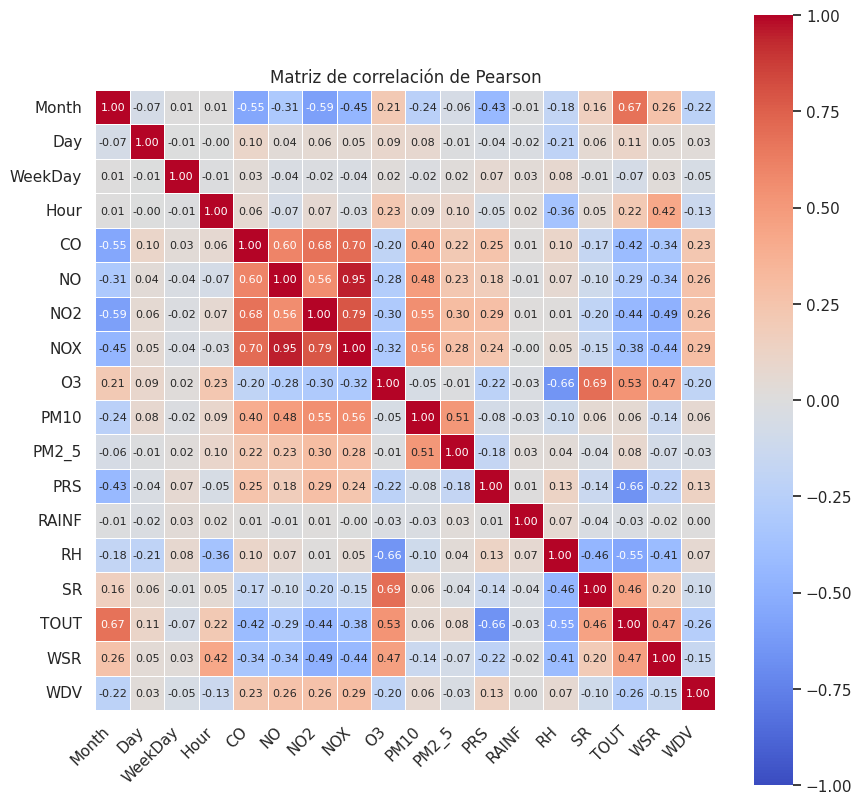

In [ ]:
import seaborn as sns
from matplotlib import pyplot as plt

sns.set(color_codes=True, font_scale=1.0)

#Establecer el tamaño de la figura
plt.figure(figsize=(10,10))

ax = sns.heatmap(
    pearson_corr_df,
    vmin=-1, vmax=1, center=0,
    cmap='coolwarm',
    square=True ,
    annot=True, fmt='.2f',
    linewidths=.5,
    annot_kws={'size': 8}
)

#titulo
ax.set_title('Matriz de correlación de Pearson');

#La barra de anotación
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    horizontalalignment='right'
);

In [ ]:
!pip install heatmapz

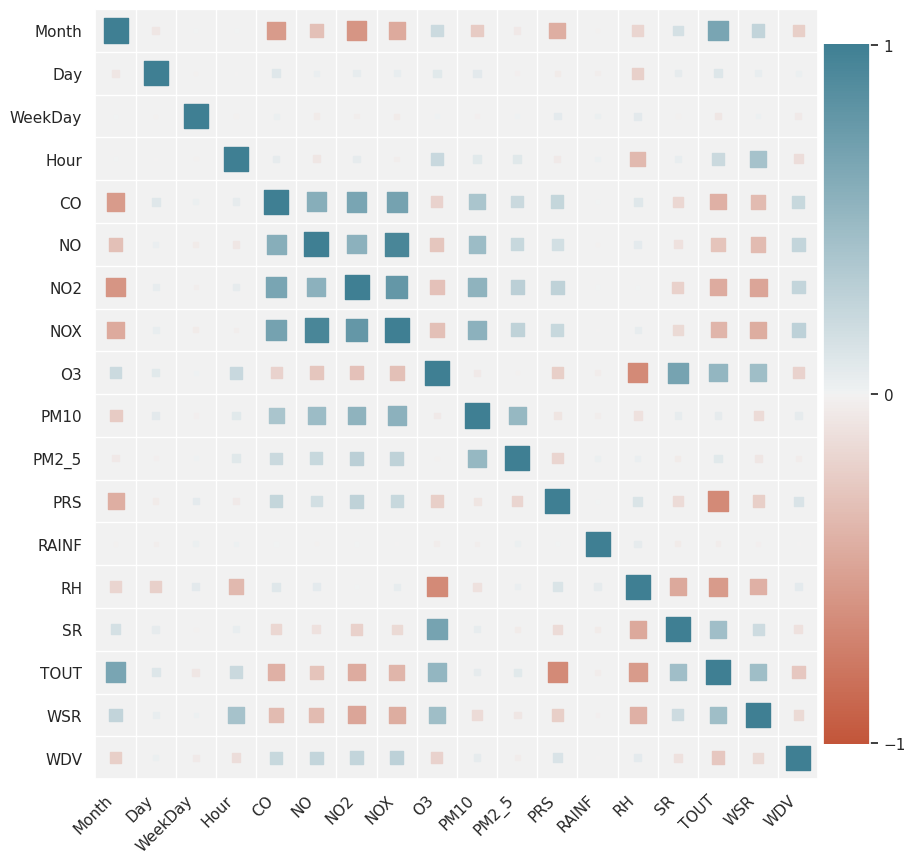

In [ ]:
# Import the two methods from heatmap library
from heatmap import corrplot

plt.figure(figsize=(10, 10))
corrplot(pearson_corr_df ,size_scale=300);

In [ ]:
df2.columns

['Date',
 'Month',
 'Day',
 'DayWeek',
 'WeekDay',
 'Hour',
 'CO',
 'NO',
 'NO2',
 'NOX',
 'O3',
 'PM10',
 'PM2_5',
 'PRS',
 'RAINF',
 'RH',
 'SR',
 'TOUT',
 'WSR',
 'WDV']

NOTA: Se eliminan 4 columnas del dataset
*  'Date', Redundante con Month/Day (eliminada al inicio por no ser númerica)
*  'DayWeek', Redundante con WeekDay
*  'NOX', Altamente correlacionado con NO (r=0.95)
*  'RAINF' Casi varianza cero (95% ceros)

In [ ]:
#limpieza de datos depues de analizar las correlaciones

columns_to_drop = [
    'Date',      # Redundante con Month/Day (eliminada al inicio por no ser númerica)
    'DayWeek',   # Redundante con WeekDay
    'NOX',       # Altamente correlacionado con NO (r=0.95)
    'RAINF'      # Casi varianza cero (95% ceros)
]
df_cleaned = df2.drop(*columns_to_drop)
print(f'Dataset inicial con {df2.columns} variables.')
print(f'Variables eliminadas: {columns_to_drop}')
print(f'Dataset final con {df_cleaned.columns} variables.')

Dataset inicial con ['Date', 'Month', 'Day', 'DayWeek', 'WeekDay', 'Hour', 'CO', 'NO', 'NO2', 'NOX', 'O3', 'PM10', 'PM2_5', 'PRS', 'RAINF', 'RH', 'SR', 'TOUT', 'WSR', 'WDV'] variables.
Variables eliminadas: ['Date', 'DayWeek', 'NOX', 'RAINF']
Dataset final con ['Month', 'Day', 'WeekDay', 'Hour', 'CO', 'NO', 'NO2', 'O3', 'PM10', 'PM2_5', 'PRS', 'RH', 'SR', 'TOUT', 'WSR', 'WDV'] variables.


#3.	Confirma estas relaciones usando gráficos de dispersión

In [ ]:
#Now we develop a scatter plot

#Select data
df_nona= df_cleaned.na.drop()
df_O3 = df_nona.select('O3')
df_RH = df_nona.select('RH')
df_SR = df_nona.select('SR')
print(df_O3.count(),df_RH.count(), df_SR.count())


3859 3859 3859


In [ ]:
#Convert to array
df_O3 = df_O3.rdd.map(lambda row : row.O3)
df_RH = df_RH.rdd.map(lambda row : row.RH)
df_SR = df_SR.rdd.map(lambda row : row.SR)
arr_O3 = df_O3.collect()
arr_RH = df_RH.collect()
arr_SR = df_SR.collect()


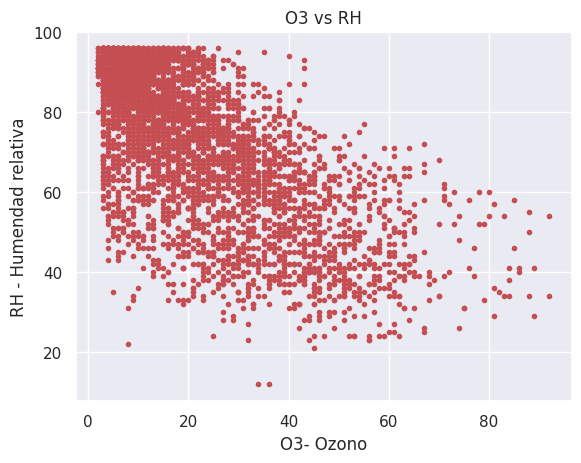

In [ ]:
#Plot
plt.plot(arr_O3,arr_RH,'r.')
plt.title('O3 vs RH')
plt.xlabel('O3- Ozono')
plt.ylabel('RH - Humendad relativa')
plt.show()


NOTA: Se muestra una correlación negativa en las características O3 vs RH

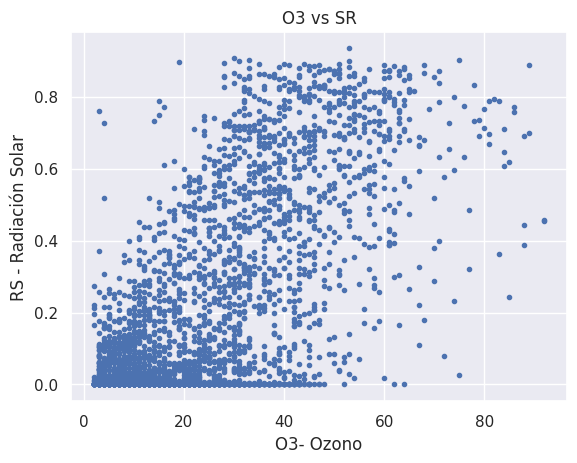

In [ ]:
#Plot
plt.plot(arr_O3,arr_SR,'b.' )
plt.title('O3 vs SR')
plt.xlabel('O3- Ozono')
plt.ylabel('RS - Radiación Solar')
plt.show()

NOTA: Se muestra una correlación negativa en las características O3 vs SR

               O3
O3       1.000000
SR       0.691927
TOUT     0.527154
WSR      0.466254
Hour     0.228381
Month    0.213890
Day      0.089457
WeekDay  0.015993
PM2_5   -0.008811
RAINF   -0.030142
PM10    -0.046893
CO      -0.196441
WDV     -0.198798
PRS     -0.219732
NO      -0.275251
NO2     -0.302997
NOX     -0.316941
RH      -0.655588


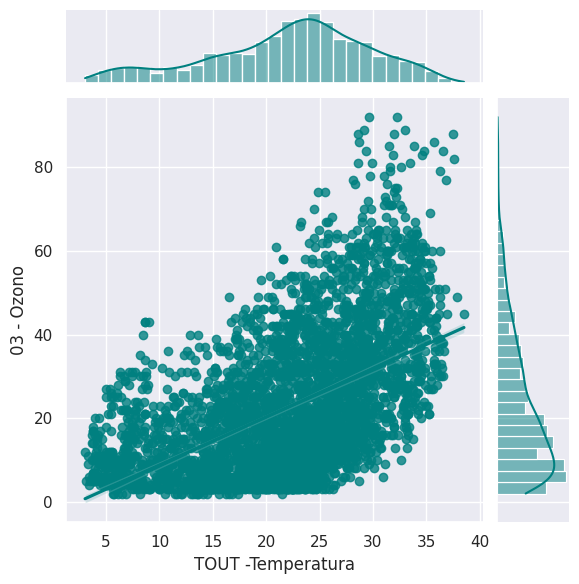

In [ ]:
# Enfocarnos solo en los contaminantes objetivo
TARGET_COLs = ['O3']
print(pearson_corr_df[TARGET_COLs].sort_values(by='O3', ascending=False))

# Visualización de dispersión con línea de regresión para O3 vs Temperatura
sns.jointplot(x='TOUT', y='O3', data=df_cleaned.toPandas(), kind='reg', color='teal')
plt.xlabel('TOUT -Temperatura')
plt.ylabel('03 - Ozono')
plt.show()

# 4. Modelos de Regresión

*Predecir estos contaminantes con la menor cantidad de variables atributos posible. Puedes utilizar cualquier técnica: regresión lineal (o polinomial) multivariable, random forrests, gradient boost, o cualquier otra técnica que hayas investigado que funcione en Spark.*

In [ ]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.regression import GBTRegressor

## Funciones

In [ ]:
def regresion_lineal(features_col, target_col, train_data, test_data):
  #Crear el modelo
  lr = LinearRegression(featuresCol = features_col, labelCol = target_col)

  #Entrenar el modelo de regresión lineal
  lr = lr.fit(train_data)

  #Aplicar el modelo
  pred_lr = lr.transform(test_data)
  pred_lr.select(features_col, target_col, 'prediction').show(10)

  return pred_lr , lr

In [ ]:
def regresion_random_forest(features_col, target_col, train_data, test_data):
  #Carry out random forrest regression
  rfr = RandomForestRegressor(featuresCol = features_col, labelCol = target_col)

  #Learn to fit the model from training set
  rfr = rfr.fit(train_data)

  #To predict the prices on testing set
  pred_rfr = rfr.transform(test_data)

  # Select example rows to display.
  pred_rfr.select(features_col, target_col, 'prediction').show(10)

  return pred_rfr

In [ ]:
def regresion_gradient_boost(features_col, target_col, train_data, test_data):
  #Carry out Gradient-boosted tree regression
  gbt = GBTRegressor(featuresCol = features_col, labelCol = target_col)

  #Learn to fit the model from training set
  gbt = gbt.fit(train_data)

  #To predict the prices on testing set
  pred_gbt = gbt.transform(test_data)

  # Select example rows to display.
  pred_gbt.select(features_col, target_col, 'prediction').show(10)
  return pred_gbt

In [ ]:
def Evaluacion_del_modelo(target_column, pred_model, model):
  #Evaluado la regresion lineal
  eval_model = RegressionEvaluator(labelCol=target_column, predictionCol='prediction', metricName='rmse')

  print('MODELO:', model)
  print('Variable objetivo:',target_column)

  # Root Mean Square Error
  rmse = eval_model.evaluate(pred_model)
  print('RMSE: %.3f' % rmse)

  # Mean Square Error
  mse = eval_model.evaluate(pred_model, {eval_model.metricName: 'mse'})
  print('MSE: %.3f' % mse)

  # Mean Absolute Error
  mae = eval_model.evaluate(pred_model, {eval_model.metricName: 'mae'})
  print('MAE: %.3f' % mae)

  # r2 - coefficient of determination
  r2 = eval_model.evaluate(pred_model, {eval_model.metricName: 'r2'})
  print('r2: %.3f' %r2)

  return rmse, mse, mae, r2

##Preparación de datos

In [ ]:
df_cleaned.printSchema()

root
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- WeekDay: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- O3: integer (nullable = true)
 |-- PM10: integer (nullable = true)
 |-- PM2_5: integer (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RH: integer (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: integer (nullable = true)



In [ ]:
# Obtenemos las columnas de las caracteristicas y eliminamos las variables objetivo
features_cols = df_cleaned.columns
features_cols.remove('O3')
features_cols.remove('PM2_5')

## 4.1: O3 (Ozono) -> Variable Objetivo

### Regresión Lineal

In [ ]:
#Input all the features in one vector column
TARGET_COL = 'O3'
FEATURES_COL = 'features'

assembler = VectorAssembler(inputCols=features_cols, outputCol=FEATURES_COL)
output = assembler.transform(df_cleaned)

#Input vs Output
finalized_data = output.select(FEATURES_COL,TARGET_COL)
finalized_data.show(10)

+--------------------+---+
|            features| O3|
+--------------------+---+
|[1.0,1.0,5.0,1.0,...| 10|
|[1.0,1.0,5.0,2.0,...|  7|
|[1.0,1.0,5.0,3.0,...|  7|
|[1.0,1.0,5.0,5.0,...|  7|
|[1.0,1.0,5.0,8.0,...|  5|
|[1.0,1.0,5.0,9.0,...|  7|
|[1.0,1.0,5.0,12.0...| 10|
|[1.0,1.0,5.0,13.0...| 12|
|[1.0,1.0,5.0,14.0...| 14|
|[1.0,1.0,5.0,15.0...| 11|
+--------------------+---+
only showing top 10 rows


In [ ]:
#Dividimos el dataset en training and testing data
train_data,test_data = finalized_data.randomSplit([0.8,0.2])

pred_lr, lr = regresion_lineal(FEATURES_COL, TARGET_COL, train_data, test_data)

+--------------------+---+------------------+
|            features| O3|        prediction|
+--------------------+---+------------------+
|[1.0,1.0,5.0,12.0...| 10| 18.00956134875645|
|[1.0,1.0,5.0,22.0...|  5|16.578118777914312|
|[1.0,1.0,5.0,23.0...|  6|17.244549675612006|
|[1.0,2.0,6.0,6.0,...|  4| 16.14674189482014|
|[1.0,2.0,6.0,9.0,...|  5|15.492666369856522|
|[1.0,3.0,7.0,6.0,...|  4|15.066457943588091|
|[1.0,3.0,7.0,8.0,...|  4|12.973340420447244|
|[1.0,3.0,7.0,9.0,...|  5|15.615499783647863|
|[1.0,3.0,7.0,14.0...| 10|20.432006698317082|
|[1.0,4.0,1.0,13.0...| 30| 43.30279870531302|
+--------------------+---+------------------+
only showing top 10 rows


In [ ]:
import numpy as np
print ('Note: the last rows are the information for Intercept')
print ('##','-------------------------------------------------')
print ('##','  Estimate   |   Std.Error | t Values  |  P-value')
coef = np.append(list(lr.coefficients),lr.intercept)
Summary=lr.summary

for i in range(len(Summary.pValues)):
    print ('##','{:10.6f}'.format(coef[i]),\
    '{:10.6f}'.format(Summary.coefficientStandardErrors[i]),\
    '{:8.3f}'.format(Summary.tValues[i]),\
    '{:10.6f}'.format(Summary.pValues[i]))

print ('##','---')
print ('##','Mean squared error: % .6f' \
        % Summary.meanSquaredError, ', \
        RMSE: % .6f' \
        % Summary.rootMeanSquaredError )
print ('##','Multiple R-squared: %f' % Summary.r2, ', \
        Total iterations: %i'% Summary.totalIterations)

Note: the last rows are the information for Intercept
## -------------------------------------------------
##   Estimate   |   Std.Error | t Values  |  P-value
##  -0.135882   0.097678   -1.391   0.164288
##  -0.057483   0.018428   -3.119   0.001829
##   0.253087   0.082574    3.065   0.002196
##  -0.027966   0.029162   -0.959   0.337641
##   3.371858   0.281900   11.961   0.000000
##  -0.098159   0.008353  -11.751   0.000000
##  -0.243627   0.024415   -9.979   0.000000
##   0.005400   0.004743    1.138   0.255015
##  -0.588328   0.064362   -9.141   0.000000
##  -0.420165   0.013995  -30.023   0.000000
##  30.152837   0.773095   39.003   0.000000
##  -0.321358   0.055358   -5.805   0.000000
##   0.562696   0.063694    8.834   0.000000
##  -0.012217   0.001802   -6.779   0.000000
## 474.878502  47.288684   10.042   0.000000
## ---
## Mean squared error:  79.092811 ,         RMSE:  8.893414
## Multiple R-squared: 0.716885 ,         Total iterations: 0


In [ ]:
print ('The coefficient of the model is : ', lr.coefficients)
print ('The Intercept of the model is : ', lr.intercept)

The coefficient of the model is :  [-0.13588192694048726,-0.0574833291921292,0.2530866286134871,-0.027965547689149824,3.3718582261759638,-0.09815902681654076,-0.24362666344896614,0.005400227642070746,-0.5883281602194137,-0.42016544344967294,30.152836959283256,-0.32135817144920564,0.5626956369557655,-0.012216943413002047]
The Intercept of the model is :  474.87850212083833


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_lr,'Linear regression')

MODELO: Linear regression
Variable objetivo: O3
RMSE: 8.389
MSE: 70.367
MAE: 6.274
r2: 0.713


(8.388502066042697, 70.36696691200261, 6.274260494251393, 0.7130744938481215)

### Regresión Random Forrest

In [ ]:
pred_rfr = regresion_random_forest(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+---+------------------+
|            features| O3|        prediction|
+--------------------+---+------------------+
|[1.0,1.0,5.0,12.0...| 10|15.381924401920127|
|[1.0,1.0,5.0,22.0...|  5| 17.90579113910735|
|[1.0,1.0,5.0,23.0...|  6| 17.90579113910735|
|[1.0,2.0,6.0,6.0,...|  4|11.423952590018455|
|[1.0,2.0,6.0,9.0,...|  5| 7.753938079717139|
|[1.0,3.0,7.0,6.0,...|  4| 6.168385165806086|
|[1.0,3.0,7.0,8.0,...|  4| 6.547306016387064|
|[1.0,3.0,7.0,9.0,...|  5| 7.753938079717139|
|[1.0,3.0,7.0,14.0...| 10| 9.391315589285963|
|[1.0,4.0,1.0,13.0...| 30| 41.31076842335186|
+--------------------+---+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_rfr,'Regression Random Forrest')

MODELO: Regression Random Forrest
Variable objetivo: O3
RMSE: 7.303
MSE: 53.340
MAE: 5.444
r2: 0.783


(7.303400366205369, 53.339656909088724, 5.443542806582359, 0.7825043663492435)

### Regresión Gradient-Boosted Regression

In [ ]:
pred_gbt = regresion_gradient_boost(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+---+------------------+
|            features| O3|        prediction|
+--------------------+---+------------------+
|[1.0,1.0,5.0,12.0...| 10| 8.194798499643108|
|[1.0,1.0,5.0,22.0...|  5|15.501993460325473|
|[1.0,1.0,5.0,23.0...|  6|19.838008555767466|
|[1.0,2.0,6.0,6.0,...|  4| 4.223629338003122|
|[1.0,2.0,6.0,9.0,...|  5| 5.184757219975688|
|[1.0,3.0,7.0,6.0,...|  4|3.0114520838610925|
|[1.0,3.0,7.0,8.0,...|  4| 6.939785758663041|
|[1.0,3.0,7.0,9.0,...|  5| 5.886767482325404|
|[1.0,3.0,7.0,14.0...| 10|  6.65807072129872|
|[1.0,4.0,1.0,13.0...| 30| 41.19707149896589|
+--------------------+---+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_gbt,'Gradient Boot Tree')

MODELO: Gradient Boot Tree
Variable objetivo: O3
RMSE: 6.298
MSE: 39.665
MAE: 4.594
r2: 0.838


(6.297977137164983, 39.66451602025283, 4.5943949165371905, 0.8382655692746777)

## 4.2: PM2.5 Particulas menores a 2.5 microns g/ m3 -> Variable Objetivo

### Regresión Lineal

In [ ]:
#Input all the features in one vector column
TARGET_COL = 'PM2_5'

assembler = VectorAssembler(inputCols=features_cols, outputCol=FEATURES_COL)
output = assembler.transform(df_cleaned)

#Input vs Output
finalized_data = output.select(FEATURES_COL,TARGET_COL)
finalized_data.show(10)

+--------------------+-----+
|            features|PM2_5|
+--------------------+-----+
|[1.0,1.0,5.0,1.0,...|   80|
|[1.0,1.0,5.0,2.0,...|   29|
|[1.0,1.0,5.0,3.0,...|    9|
|[1.0,1.0,5.0,5.0,...|   14|
|[1.0,1.0,5.0,8.0,...|    8|
|[1.0,1.0,5.0,9.0,...|    6|
|[1.0,1.0,5.0,12.0...|   17|
|[1.0,1.0,5.0,13.0...|   16|
|[1.0,1.0,5.0,14.0...|   19|
|[1.0,1.0,5.0,15.0...|   35|
+--------------------+-----+
only showing top 10 rows


In [ ]:
#Dividimos el dataset en training and testing data
train_data,test_data = finalized_data.randomSplit([0.8,0.2])

pred_lr, lr = regresion_lineal(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+-----+------------------+
|            features|PM2_5|        prediction|
+--------------------+-----+------------------+
|[1.0,1.0,5.0,1.0,...|   80|27.521159560089757|
|[1.0,1.0,5.0,9.0,...|    6|12.012494340939213|
|[1.0,1.0,5.0,13.0...|   16|18.116553593526874|
|[1.0,1.0,5.0,17.0...|   36|24.172620650042234|
|[1.0,2.0,6.0,0.0,...|   12|11.696666234384224|
|[1.0,2.0,6.0,12.0...|   10|18.174702359105197|
|[1.0,2.0,6.0,20.0...|   28| 22.98155440612959|
|[1.0,2.0,6.0,21.0...|   40|  22.4481011436892|
|[1.0,3.0,7.0,17.0...|   71| 31.41915390847231|
|[1.0,3.0,7.0,19.0...|   94|48.926801227336966|
+--------------------+-----+------------------+
only showing top 10 rows


In [ ]:
import numpy as np
print ('Note: the last rows are the information for Intercept')
print ('##','-------------------------------------------------')
print ('##','  Estimate   |   Std.Error | t Values  |  P-value')
coef = np.append(list(lr.coefficients),lr.intercept)
Summary=lr.summary

for i in range(len(Summary.pValues)):
    print ('##','{:10.6f}'.format(coef[i]),\
    '{:10.6f}'.format(Summary.coefficientStandardErrors[i]),\
    '{:8.3f}'.format(Summary.tValues[i]),\
    '{:10.6f}'.format(Summary.pValues[i]))

print ('##','---')
print ('##','Mean squared error: % .6f' \
        % Summary.meanSquaredError, ', \
        RMSE: % .6f' \
        % Summary.rootMeanSquaredError )
print ('##','Multiple R-squared: %f' % Summary.r2, ', \
        Total iterations: %i'% Summary.totalIterations)

Note: the last rows are the information for Intercept
## -------------------------------------------------
##   Estimate   |   Std.Error | t Values  |  P-value
##   0.592584   0.155150    3.819   0.000136
##  -0.045959   0.028584   -1.608   0.107965
##   0.119579   0.127808    0.936   0.349542
##   0.121896   0.044802    2.721   0.006550
##   0.680017   0.439389    1.548   0.121810
##   0.010774   0.012858    0.838   0.402162
##   0.276500   0.038297    7.220   0.000000
##   0.145044   0.007281   19.922   0.000000
##  -0.528154   0.100150   -5.274   0.000000
##   0.171790   0.021582    7.960   0.000000
##  -1.685914   1.190901   -1.416   0.156975
##   0.194472   0.086718    2.243   0.024994
##   0.320187   0.098274    3.258   0.001134
##  -0.010128   0.002744   -3.691   0.000227
## 367.759003  73.613312    4.996   0.000001
## ---
## Mean squared error:  189.252190 ,         RMSE:  13.756896
## Multiple R-squared: 0.325519 ,         Total iterations: 0


In [ ]:
print ('The coefficient of the model is : ', lr.coefficients)
print ('The Intercept of the model is : ', lr.intercept)

The coefficient of the model is :  [0.5925842634737103,-0.045958614446161374,0.11957940306846508,0.1218964458178893,0.6800172772546669,0.010773793837263106,0.276499775642471,0.1450439361998672,-0.5281535177426057,0.17178951840092455,-1.685914480256174,0.19447246024077322,0.32018665520402,-0.010127662298740254]
The Intercept of the model is :  367.75900274703696


Evaluación del modelo


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_lr,'Linear regression')

MODELO: Linear regression
Variable objetivo: PM2_5
RMSE: 14.463
MSE: 209.186
MAE: 10.977
r2: 0.296


(14.46326980570456, 209.1861734726052, 10.97700296647325, 0.2964414852622199)

### Regresión Random Forrest

In [ ]:
pred_rfr = regresion_random_forest(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+-----+------------------+
|            features|PM2_5|        prediction|
+--------------------+-----+------------------+
|[1.0,1.0,5.0,1.0,...|   80| 31.08841728443959|
|[1.0,1.0,5.0,9.0,...|    6|13.817888808421628|
|[1.0,1.0,5.0,13.0...|   16|16.374954048645233|
|[1.0,1.0,5.0,17.0...|   36| 23.91078387320247|
|[1.0,2.0,6.0,0.0,...|   12|15.396180102254561|
|[1.0,2.0,6.0,12.0...|   10|18.192747828952317|
|[1.0,2.0,6.0,20.0...|   28| 22.94737039228737|
|[1.0,2.0,6.0,21.0...|   40|21.598018771614022|
|[1.0,3.0,7.0,17.0...|   71|33.579983608489435|
|[1.0,3.0,7.0,19.0...|   94| 79.29103547493615|
+--------------------+-----+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_rfr,'Regression Random Forrest')

MODELO: Regression Random Forrest
Variable objetivo: PM2_5
RMSE: 14.019
MSE: 196.527
MAE: 10.783
r2: 0.339


(14.018826234408525, 196.5274889905407, 10.78270654750791, 0.33901659959644637)

### Regresión Gradient-Boosted Regression

In [ ]:
pred_gbt = regresion_gradient_boost(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+-----+------------------+
|            features|PM2_5|        prediction|
+--------------------+-----+------------------+
|[1.0,1.0,5.0,1.0,...|   80|29.889787306378974|
|[1.0,1.0,5.0,9.0,...|    6|11.438352482815404|
|[1.0,1.0,5.0,13.0...|   16|16.225217330212324|
|[1.0,1.0,5.0,17.0...|   36|25.979690108199716|
|[1.0,2.0,6.0,0.0,...|   12|13.138065144098796|
|[1.0,2.0,6.0,12.0...|   10|17.884141426851947|
|[1.0,2.0,6.0,20.0...|   28|17.989670430999215|
|[1.0,2.0,6.0,21.0...|   40|  18.8165037058627|
|[1.0,3.0,7.0,17.0...|   71|31.683679248305058|
|[1.0,3.0,7.0,19.0...|   94| 86.37027037832264|
+--------------------+-----+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_gbt,'Gradient Boot Tree')

MODELO: Gradient Boot Tree
Variable objetivo: PM2_5
RMSE: 13.948
MSE: 194.558
MAE: 10.585
r2: 0.346


(13.948410379401993,
 194.55815211220926,
 10.585383595131342,
 0.34564009533775863)

#5. Mejoras al modelo  (Agrupación por fecha)


•	Si los niveles de los contaminantes son bajos, no es relevante. Lo único que importa es cuando los niveles son altos.


•	Modifica la tabla agrupando los datos por día y obteniendo el valor máximo para O3 y PM2.5 en cada día.


•	 Ahora obtén el mínimo, el promedio y el máximo de cada variable del clima, creando una tabla como la que sigue:


## Preparación de los datos

In [ ]:
df_cleaned.printSchema()

root
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- WeekDay: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- O3: integer (nullable = true)
 |-- PM10: integer (nullable = true)
 |-- PM2_5: integer (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RH: integer (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: integer (nullable = true)



In [ ]:
df_cleaned.show(10)

+-----+---+-------+----+----+----+----+---+----+-----+-----+---+-----+----+---+---+
|Month|Day|WeekDay|Hour|  CO|  NO| NO2| O3|PM10|PM2_5|  PRS| RH|   SR|TOUT|WSR|WDV|
+-----+---+-------+----+----+----+----+---+----+-----+-----+---+-----+----+---+---+
|    1|  1|      5|   1|2.51|10.2|12.9| 10| 139|   80|725.4| 96|  0.0|3.91|7.2|344|
|    1|  1|      5|   2|2.41| 9.2|11.6|  7|  42|   29|725.0| 96|  0.0|3.81|6.3|341|
|    1|  1|      5|   3|2.39| 8.1|11.8|  7|  23|    9|724.4| 96|  0.0|3.85|5.2|346|
|    1|  1|      5|   5|2.26| 5.3| 8.9|  7|  23|   14|724.0| 96|  0.0|3.79|5.6|336|
|    1|  1|      5|   8|2.25| 7.2|10.2|  5|  15|    8|724.3| 96|0.023|3.93|4.8|354|
|    1|  1|      5|   9|2.21| 5.8| 8.2|  7|  16|    6|724.3| 96|0.052|4.13|4.2| 15|
|    1|  1|      5|  12|2.38|10.0|10.1| 10|  22|   17|722.6| 96|0.127| 6.6|3.2| 29|
|    1|  1|      5|  13|2.51|11.5|12.3| 12|  32|   16|721.7| 95| 0.15|6.89|4.8|  2|
|    1|  1|      5|  14|2.55|12.0|13.5| 14|  31|   19|721.0| 94|0.175|7.43|4

In [ ]:
#agregar una columna
from pyspark.sql.functions import col, concat_ws, lit, to_date, max, min, avg
from pyspark.sql import functions as sf

#Crea la nueva columna DATE con los campos y el año se fija
df_date = df_cleaned.withColumn(
    'Date',
    to_date(
          concat_ws('-', col('Day').cast('string'), col('Month').cast('string'), lit('2015'))
          ,'d-M-yyyy')
)

# Eliminamos las columnas no necesarias para agrupación
df_opt = df_date.drop('Month','Day','Hour','WeekDay')

# De todas las caracteristicas se omiten las variables objetivo (O3, PM2_5) y la fecha.
climate_vars = [c for c in df_opt.columns if c not in ['Date','O3','PM2_5']]


# Lista de expresiones de agregación
agg_expressions = [
    max(col('O3')).alias('max_O3'),
    max(col('PM2_5')).alias('max_PM2_5')
]

for var in climate_vars:
    agg_expressions.append(min(col(var)).alias(f'min_{var}'))
    agg_expressions.append(avg(col(var)).alias(f'avg_{var}'))
    agg_expressions.append(max(col(var)).alias(f'max_{var}'))

#Agrupamos por fecha
df_gpo = df_opt.groupBy('Date').agg(*agg_expressions).sort('Date')

print('Aggregated DataFrame (Max O3, Max PM2.5, Min/Avg/Max for other climate variables):')
df_gpo.show(10)


Aggregated DataFrame (Max O3, Max PM2.5, Min/Avg/Max for other climate variables):
+----------+------+---------+------+------------------+------+------+------------------+------+-------+------------------+-------+--------+------------------+--------+-------+-----------------+-------+------+------------------+------+------+--------------------+------+--------+------------------+--------+-------+------------------+-------+-------+------------------+-------+
|      Date|max_O3|max_PM2_5|min_CO|            avg_CO|max_CO|min_NO|            avg_NO|max_NO|min_NO2|           avg_NO2|max_NO2|min_PM10|          avg_PM10|max_PM10|min_PRS|          avg_PRS|max_PRS|min_RH|            avg_RH|max_RH|min_SR|              avg_SR|max_SR|min_TOUT|          avg_TOUT|max_TOUT|min_WSR|           avg_WSR|max_WSR|min_WDV|           avg_WDV|max_WDV|
+----------+------+---------+------+------------------+------+------+------------------+------+-------+------------------+-------+--------+------------------+-----

In [ ]:
df_gpo.printSchema()

root
 |-- Date: date (nullable = false)
 |-- max_O3: integer (nullable = true)
 |-- max_PM2_5: integer (nullable = true)
 |-- min_CO: double (nullable = true)
 |-- avg_CO: double (nullable = true)
 |-- max_CO: double (nullable = true)
 |-- min_NO: double (nullable = true)
 |-- avg_NO: double (nullable = true)
 |-- max_NO: double (nullable = true)
 |-- min_NO2: double (nullable = true)
 |-- avg_NO2: double (nullable = true)
 |-- max_NO2: double (nullable = true)
 |-- min_PM10: integer (nullable = true)
 |-- avg_PM10: double (nullable = true)
 |-- max_PM10: integer (nullable = true)
 |-- min_PRS: double (nullable = true)
 |-- avg_PRS: double (nullable = true)
 |-- max_PRS: double (nullable = true)
 |-- min_RH: integer (nullable = true)
 |-- avg_RH: double (nullable = true)
 |-- max_RH: integer (nullable = true)
 |-- min_SR: double (nullable = true)
 |-- avg_SR: double (nullable = true)
 |-- max_SR: double (nullable = true)
 |-- min_TOUT: double (nullable = true)
 |-- avg_TOUT: double (nu

##5.1: O3 (Ozono) -> Variable Objetivo

### Regresión Lineal

In [ ]:
#realizamos el modelo de regresión lineal
#Input all the features in one vector column
TARGET_COL = 'max_O3'
FEATURES_COL = 'features'

features_cols = df_gpo.columns
features_cols.remove('Date')
features_cols.remove(TARGET_COL)

assembler = VectorAssembler(inputCols=features_cols, outputCol=FEATURES_COL)
output = assembler.transform(df_gpo)

#Input vs Output
finalized_data = output.select(FEATURES_COL,TARGET_COL)
finalized_data.show(10)

+--------------------+------+
|            features|max_O3|
+--------------------+------+
|[80.0,2.21,2.4729...|    14|
|[52.0,2.19,2.5333...|    10|
|[119.0,2.22,3.061...|    13|
|[45.0,2.3,2.60888...|    31|
|[55.0,2.18,2.516,...|    36|
|[105.0,2.36,3.035...|    49|
|[43.0,2.57,2.6916...|    20|
|[52.0,2.26,2.5095...|    31|
|[40.0,2.46,2.7375...|    13|
|[18.0,2.32,2.6833...|    14|
+--------------------+------+
only showing top 10 rows


In [ ]:
#Dividimos el dataset en training and testing data
train_data,test_data = finalized_data.randomSplit([0.8,0.2])

pred_lr, lr = regresion_lineal(FEATURES_COL, TARGET_COL, train_data, test_data)



+--------------------+------+------------------+
|            features|max_O3|        prediction|
+--------------------+------+------------------+
|[11.0,0.52,0.5700...|    21| 27.94898485835779|
|[21.0,2.44,2.7764...|    12|  6.82534444697194|
|[24.0,2.64,2.8581...|    25| 36.64162161314607|
|[25.0,1.28,1.29,1...|    24|11.789814219649088|
|[26.0,1.85,2.0571...|    19| 4.919623405973198|
|[28.0,1.01,1.2441...|    43|15.883979250262655|
|[29.0,0.67,0.865,...|    18|25.730170971503185|
|[33.0,1.73,2.036,...|    20| 11.82187153047198|
|[34.0,1.22,1.3708...|    64|60.730696438235896|
|[37.0,1.25,1.6395...|    22| 18.00598845458535|
+--------------------+------+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_lr,'Linear regression')

MODELO: Linear regression
Variable objetivo: max_O3
RMSE: 11.933
MSE: 142.397
MAE: 9.815
r2: 0.591


(11.93300379913851, 142.39657967025408, 9.814987346858075, 0.5908255395494528)

### Regresión Random Forrest

In [ ]:
pred_rfr = regresion_random_forest(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+------+------------------+
|            features|max_O3|        prediction|
+--------------------+------+------------------+
|[11.0,0.52,0.5700...|    21| 47.12400730495558|
|[21.0,2.44,2.7764...|    12|16.813792482027775|
|[24.0,2.64,2.8581...|    25| 29.33766417678182|
|[25.0,1.28,1.29,1...|    24| 22.21581501831502|
|[26.0,1.85,2.0571...|    19| 17.87082286994052|
|[28.0,1.01,1.2441...|    43| 24.91312814636344|
|[29.0,0.67,0.865,...|    18|19.119216894216894|
|[33.0,1.73,2.036,...|    20|20.235757934875586|
|[34.0,1.22,1.3708...|    64|  64.7533914282723|
|[37.0,1.25,1.6395...|    22| 21.45053795877325|
+--------------------+------+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_rfr,'Regression Random Forrest')

MODELO: Regression Random Forrest
Variable objetivo: max_O3
RMSE: 11.417
MSE: 130.346
MAE: 8.365
r2: 0.625


(11.416934481619085, 130.34639295758285, 8.364942287703274, 0.6254515724071479)

 ### Regresión Gradient-Boosted Regression

In [ ]:
pred_gbt = regresion_gradient_boost(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+------+------------------+
|            features|max_O3|        prediction|
+--------------------+------+------------------+
|[11.0,0.52,0.5700...|    21| 55.28132227144239|
|[21.0,2.44,2.7764...|    12|16.259901095165215|
|[24.0,2.64,2.8581...|    25|38.278655959395195|
|[25.0,1.28,1.29,1...|    24|16.934629025912134|
|[26.0,1.85,2.0571...|    19|19.135272578417347|
|[28.0,1.01,1.2441...|    43|21.251962325377807|
|[29.0,0.67,0.865,...|    18|12.246630086124137|
|[33.0,1.73,2.036,...|    20| 19.24159169145499|
|[34.0,1.22,1.3708...|    64|60.528167307170115|
|[37.0,1.25,1.6395...|    22|24.108407870643493|
+--------------------+------+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_gbt,'Gradient Boot Tree')

MODELO: Gradient Boot Tree
Variable objetivo: max_O3
RMSE: 14.677
MSE: 215.427
MAE: 11.380
r2: 0.381


(14.677415570244397, 215.42652782165268, 11.379876450836738, 0.380975066309314)

##5.2: PM2.5 Particulas menores a 2.5 microns g/ m3 -> Variable Objetivo

### Regresión Lineal

In [ ]:
#realizamos el modelo de regresión lineal
#Input all the features in one vector column
TARGET_COL = 'max_PM2_5'
FEATURES_COL = 'features'

features_cols = df_gpo.columns
features_cols.remove('Date')
features_cols.remove(TARGET_COL)

assembler = VectorAssembler(inputCols=features_cols, outputCol=FEATURES_COL)
output = assembler.transform(df_gpo)

#Input vs Output
finalized_data = output.select(FEATURES_COL,TARGET_COL)
finalized_data.show(10)

+--------------------+---------+
|            features|max_PM2_5|
+--------------------+---------+
|[14.0,2.21,2.4729...|       80|
|[10.0,2.19,2.5333...|       52|
|[13.0,2.22,3.0611...|      119|
|[31.0,2.3,2.60888...|       45|
|[36.0,2.18,2.516,...|       55|
|[49.0,2.36,3.0352...|      105|
|[20.0,2.57,2.6916...|       43|
|[31.0,2.26,2.5095...|       52|
|[13.0,2.46,2.7375...|       40|
|[14.0,2.32,2.6833...|       18|
+--------------------+---------+
only showing top 10 rows


In [ ]:
#Dividimos el dataset en training and testing data
train_data,test_data = finalized_data.randomSplit([0.8,0.2])

pred_lr, lr = regresion_lineal (FEATURES_COL, TARGET_COL, train_data, test_data)



+--------------------+---------+------------------+
|            features|max_PM2_5|        prediction|
+--------------------+---------+------------------+
|[5.0,2.42,2.435,2...|       15|13.156524561288961|
|[13.0,1.97,1.98,1...|       21| 32.62828385544441|
|[13.0,2.46,2.7375...|       40| 32.66922033747153|
|[14.0,2.21,2.4729...|       80| 51.34046543990729|
|[18.0,2.45,2.79,3...|       31| 40.91441352950136|
|[20.0,1.61,1.8900...|       42| 59.70324251451268|
|[20.0,1.73,2.036,...|       33|48.969863791797366|
|[24.0,1.28,1.29,1...|       25| 24.09687310129891|
|[28.0,0.69,0.8517...|       40| 43.96970349305951|
|[29.0,0.98,1.6869...|       66|54.889706527055864|
+--------------------+---------+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_lr,'Linear regression')

MODELO: Linear regression
Variable objetivo: max_PM2_5
RMSE: 16.489
MSE: 271.881
MAE: 12.334
r2: 0.381


(16.48882094846241, 271.8812162704529, 12.333880497914675, 0.3814569784914015)

### Regresión Random Forrest

In [ ]:
pred_rfr = regresion_random_forest(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+---------+------------------+
|            features|max_PM2_5|        prediction|
+--------------------+---------+------------------+
|[5.0,2.42,2.435,2...|       15|26.413333333333334|
|[13.0,1.97,1.98,1...|       21|40.711432957928686|
|[13.0,2.46,2.7375...|       40|45.423222349545874|
|[14.0,2.21,2.4729...|       80|55.664680883896644|
|[18.0,2.45,2.79,3...|       31| 44.33120080759576|
|[20.0,1.61,1.8900...|       42| 49.38058295412074|
|[20.0,1.73,2.036,...|       33| 42.21868659249287|
|[24.0,1.28,1.29,1...|       25|31.577375241038027|
|[28.0,0.69,0.8517...|       40| 45.04544019453907|
|[29.0,0.98,1.6869...|       66|  71.0533262917638|
+--------------------+---------+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_rfr,'Regression Random Forrest')

MODELO: Regression Random Forrest
Variable objetivo: max_PM2_5
RMSE: 17.088
MSE: 292.001
MAE: 13.317
r2: 0.336


(17.088034220797777, 292.00091353115585, 13.31710474287514, 0.3356836863670425)

 ### Regresión Gradient-Boosted Regression

In [ ]:
pred_gbt = regresion_gradient_boost(FEATURES_COL, TARGET_COL, train_data, test_data)


+--------------------+---------+------------------+
|            features|max_PM2_5|        prediction|
+--------------------+---------+------------------+
|[5.0,2.42,2.435,2...|       15|17.658630085071575|
|[13.0,1.97,1.98,1...|       21| 22.63821450283548|
|[13.0,2.46,2.7375...|       40| 42.32284619607962|
|[14.0,2.21,2.4729...|       80| 96.37979780504806|
|[18.0,2.45,2.79,3...|       31| 41.27498501909971|
|[20.0,1.61,1.8900...|       42| 51.42791680240738|
|[20.0,1.73,2.036,...|       33|44.466691495427355|
|[24.0,1.28,1.29,1...|       25|16.709244906642084|
|[28.0,0.69,0.8517...|       40| 42.39529967422729|
|[29.0,0.98,1.6869...|       66| 75.95057490584392|
+--------------------+---------+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_gbt,'Gradient Boot Tree')

MODELO: Gradient Boot Tree
Variable objetivo: max_PM2_5
RMSE: 18.915
MSE: 357.768
MAE: 14.358
r2: 0.186


(18.91476893492595,
 357.76848386163977,
 14.358232275610847,
 0.18605925762743292)

# 6. Explorando otro modelo (XGBoost)

## Ajuste de Hiperparámetros

In [ ]:
df_cleaned.printSchema()

root
 |-- Month: integer (nullable = true)
 |-- Day: integer (nullable = true)
 |-- WeekDay: integer (nullable = true)
 |-- Hour: integer (nullable = true)
 |-- CO: double (nullable = true)
 |-- NO: double (nullable = true)
 |-- NO2: double (nullable = true)
 |-- O3: integer (nullable = true)
 |-- PM10: integer (nullable = true)
 |-- PM2_5: integer (nullable = true)
 |-- PRS: double (nullable = true)
 |-- RH: integer (nullable = true)
 |-- SR: double (nullable = true)
 |-- TOUT: double (nullable = true)
 |-- WSR: double (nullable = true)
 |-- WDV: integer (nullable = true)



In [ ]:
# Obtenemos las columnas de las caracteristicas y eliminamos las variables objetivo
features_cols = df_cleaned.columns
features_cols.remove('O3')
features_cols.remove('PM2_5')

## O3 (Ozono)

In [ ]:
#Input all the features in one vector column
TARGET_COL = 'O3'
FEATURES_COL = 'features'

assembler = VectorAssembler(inputCols=features_cols, outputCol=FEATURES_COL)
output = assembler.transform(df_cleaned)

#Input vs Output
finalized_data = output.select(FEATURES_COL,TARGET_COL)
finalized_data.show(10)

+--------------------+---+
|            features| O3|
+--------------------+---+
|[1.0,1.0,5.0,1.0,...| 10|
|[1.0,1.0,5.0,2.0,...|  7|
|[1.0,1.0,5.0,3.0,...|  7|
|[1.0,1.0,5.0,5.0,...|  7|
|[1.0,1.0,5.0,8.0,...|  5|
|[1.0,1.0,5.0,9.0,...|  7|
|[1.0,1.0,5.0,12.0...| 10|
|[1.0,1.0,5.0,13.0...| 12|
|[1.0,1.0,5.0,14.0...| 14|
|[1.0,1.0,5.0,15.0...| 11|
+--------------------+---+
only showing top 10 rows


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingRegressor

#Dividimos el dataset en training and testing data
train_data,test_data = finalized_data.randomSplit([0.8,0.2])

#Definir el 'espacio de búsqueda'
param_dist = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.8, 0.9],
    'max_features': ['sqrt', None] # 'sqrt' reduce el overfitting
}

#Configurar la búsqueda automática
#cv=5 significa que probará cada combinación en 5 cortes diferentes del dataset
random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# Convert PySpark DataFrame to Pandas DataFrame/NumPy array for scikit-learn
X_train_pd = train_data.select(FEATURES_COL).toPandas()
y_train_pd = train_data.select(TARGET_COL).toPandas()

X_train_array = np.array(X_train_pd[FEATURES_COL].tolist())
y_train_array = y_train_pd[TARGET_COL].values.ravel()

#Entrenar y encontrar el mejor
random_search.fit(X_train_array, y_train_array)

print(f'Mejores hiperparámetros: {random_search.best_params_}')
best_model = random_search.best_estimator_

Mejores hiperparámetros: {'subsample': 0.9, 'n_estimators': 500, 'max_features': None, 'max_depth': 6, 'learning_rate': 0.05}


In [ ]:
#Aplicamos los mejores hiperparámetros
from xgboost.spark import SparkXGBRegressor

# Crear el estimador con parámetros
xgbt = SparkXGBRegressor(
    FEATURES_COL = FEATURES_COL,
    label_col = TARGET_COL,
    max_depth=6,
    learning_rate=0.05,
    n_estimators=500,
    subsample=0.9,
    max_features=None,
    num_workers=2  # Número de ejecutores/tareas
)

#Learn to fit the model from training set
xgbt = xgbt.fit(train_data)

#To predict the prices on testing set
pred_gbt = xgbt.transform(test_data)

# Select example rows to display.
pred_gbt.select(FEATURES_COL, TARGET_COL, 'prediction').show(10)

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 2 workers with
	booster params: {'objective': 'reg:squarederror', 'device': 'cpu', 'learning_rate': 0.05, 'max_depth': 6, 'subsample': 0.9, 'FEATURES_COL': 'features', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 500}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


+--------------------+---+------------------+
|            features| O3|        prediction|
+--------------------+---+------------------+
|[1.0,1.0,5.0,1.0,...| 10| 7.636491775512695|
|[1.0,1.0,5.0,2.0,...|  7| 6.683285236358643|
|[1.0,1.0,5.0,12.0...| 10|11.622917175292969|
|[1.0,1.0,5.0,14.0...| 14|12.195801734924316|
|[1.0,2.0,6.0,8.0,...|  4| 5.370519161224365|
|[1.0,2.0,6.0,20.0...|  4|3.7416906356811523|
|[1.0,2.0,6.0,22.0...|  4|3.1529765129089355|
|[1.0,3.0,7.0,5.0,...|  4|  4.29690408706665|
|[1.0,4.0,1.0,16.0...| 31|33.652828216552734|
|[1.0,5.0,2.0,8.0,...|  9|  8.58053207397461|
+--------------------+---+------------------+
only showing top 10 rows


In [ ]:
pred_gbt.dtypes

[('features', 'vector'), ('O3', 'int'), ('prediction', 'double')]

In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_gbt,'XGBoost regression')

MODELO: XGBoost regression
Variable objetivo: O3
RMSE: 4.061
MSE: 16.493
MAE: 2.806
r2: 0.943


(4.061188060839495, 16.493248465505253, 2.8060010342500896, 0.9425958043062116)

## PM 2.5

In [ ]:
#Input all the features in one vector column
TARGET_COL = 'PM2_5'
FEATURES_COL = 'features'

assembler = VectorAssembler(inputCols=features_cols, outputCol=FEATURES_COL)
output = assembler.transform(df_cleaned)

#Input vs Output
finalized_data = output.select(FEATURES_COL,TARGET_COL)
finalized_data.show(10)

+--------------------+-----+
|            features|PM2_5|
+--------------------+-----+
|[1.0,1.0,5.0,1.0,...|   80|
|[1.0,1.0,5.0,2.0,...|   29|
|[1.0,1.0,5.0,3.0,...|    9|
|[1.0,1.0,5.0,5.0,...|   14|
|[1.0,1.0,5.0,8.0,...|    8|
|[1.0,1.0,5.0,9.0,...|    6|
|[1.0,1.0,5.0,12.0...|   17|
|[1.0,1.0,5.0,13.0...|   16|
|[1.0,1.0,5.0,14.0...|   19|
|[1.0,1.0,5.0,15.0...|   35|
+--------------------+-----+
only showing top 10 rows


In [ ]:

#Dividimos el dataset en training and testing data
train_data,test_data = finalized_data.randomSplit([0.8,0.2])

#Definir el 'espacio de búsqueda'
param_dist = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [4, 5, 6],
    'subsample': [0.8, 0.9],
    'max_features': ['sqrt', None] # 'sqrt' reduce el overfitting
}

#Configurar la búsqueda automática
#cv=5 significa que probará cada combinación en 5 cortes diferentes del dataset
random_search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=10,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    random_state=42
)

# Convert PySpark DataFrame to Pandas DataFrame/NumPy array for scikit-learn
X_train_pd = train_data.select(FEATURES_COL).toPandas()
y_train_pd = train_data.select(TARGET_COL).toPandas()

X_train_array = np.array(X_train_pd[FEATURES_COL].tolist())
y_train_array = y_train_pd[TARGET_COL].values.ravel()

#Entrenar y encontrar el mejor
random_search.fit(X_train_array, y_train_array)

print(f'Mejores hiperparámetros: {random_search.best_params_}')
best_model = random_search.best_estimator_

Mejores hiperparámetros: {'subsample': 0.8, 'n_estimators': 500, 'max_features': None, 'max_depth': 6, 'learning_rate': 0.01}


In [ ]:
#Aplicamos los mejores hiperparámetros
from xgboost.spark import SparkXGBRegressor

# Crear el estimador con parámetros
xgbt = SparkXGBRegressor(
    FEATURES_COL = FEATURES_COL,
    label_col = TARGET_COL,
    max_depth=4,
    learning_rate=0.01,
    n_estimators=1500,
    subsample=0.8,
    max_features=None,
    num_workers=2  # Número de ejecutores/tareas
)

#Learn to fit the model from training set
xgbt = xgbt.fit(train_data)

#To predict the prices on testing set
pred_gbt = xgbt.transform(test_data)

# Select example rows to display.
pred_gbt.select(FEATURES_COL, TARGET_COL, 'prediction').show(10)

INFO:XGBoost-PySpark:Running xgboost-3.2.0 on 2 workers with
	booster params: {'objective': 'reg:squarederror', 'device': 'cpu', 'learning_rate': 0.01, 'max_depth': 4, 'subsample': 0.8, 'FEATURES_COL': 'features', 'nthread': 1}
	train_call_kwargs_params: {'verbose_eval': True, 'num_boost_round': 1500}
	dmatrix_kwargs: {'nthread': 1, 'missing': nan}
INFO:XGBoost-PySpark:Finished xgboost training!


+--------------------+-----+------------------+
|            features|PM2_5|        prediction|
+--------------------+-----+------------------+
|[1.0,1.0,5.0,5.0,...|   14|11.985702514648438|
|[1.0,2.0,6.0,2.0,...|   12|11.390543937683105|
|[1.0,2.0,6.0,17.0...|   29|30.235078811645508|
|[1.0,2.0,6.0,20.0...|   28|24.906347274780273|
|[1.0,3.0,7.0,2.0,...|   12|13.374671936035156|
|[1.0,3.0,7.0,5.0,...|   10| 19.31550407409668|
|[1.0,3.0,7.0,10.0...|   35|24.514957427978516|
|[1.0,3.0,7.0,11.0...|    6|24.277366638183594|
|[1.0,6.0,3.0,2.0,...|   33|19.740381240844727|
|[1.0,6.0,3.0,11.0...|   24|30.140344619750977|
+--------------------+-----+------------------+
only showing top 10 rows


In [ ]:
Evaluacion_del_modelo(TARGET_COL, pred_gbt,'XGBoost regression')

MODELO: XGBoost regression
Variable objetivo: PM2_5
RMSE: 12.587
MSE: 158.438
MAE: 9.632
r2: 0.413


(12.587215894272099, 158.43800396901614, 9.632187460228156, 0.4129268320349301)



---

